
<p style="font-size:30px;">CREDIT CARD FRAUD DETECTION
 
PROJECT OVERVIEW:
This project analyzes a credit card transactions dataset to identify patterns that may indicate fraudulent activities. 
The goal is to explore the dataset, detect anomalies, and generate insights that can help reduce fraud.</p>

In [ ]:
pip install pandas matplotlib seaborn openpyxl

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- -------------------------- 1/3 [openpyxl]
   ------------- ------------------------

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

#For better visuals
sns.set(style="whitegrid")
%matplotlib inline

In [ ]:
import warnings
warnings.simplefilter("ignore")


In [ ]:
from IPython import get_ipython
%reset -sf

In [ ]:
import pandas as pd
file_path = 'Credit_Card_Fraud.csv'
df = pd.read_csv(file_path)

In [ ]:
print("Data Overview:")
print(df.info())

Data Overview:
<class 'pandas.DataFrame'>
RangeIndex: 53000 entries, 0 to 52999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   transaction_id      53000 non-null  str  
 1   customer_id         53000 non-null  str  
 2   transaction_amount  50922 non-null  str  
 3   merchant_category   50936 non-null  str  
 4   city                49386 non-null  str  
 5   device_type         50872 non-null  str  
 6   transaction_time    53000 non-null  str  
 7   is_fraud            53000 non-null  int64
dtypes: int64(1), str(7)
memory usage: 3.2 MB
None


In [ ]:
df.head(5)

,transaction_id,customer_id,transaction_amount,merchant_category,city,device_type,transaction_time,is_fraud,hour,day_of_week,time_diff,customer_txn_count
10653,TXN1024817,CUST1000,47.81,Online Retail,Kano,Unknown,2024-02-24 12:13:00,0,12,Saturday,NaN,6
15338,TXN1016848,CUST1000,59.56,Utility Bills,Abuja,Mobile,2024-07-29 15:37:00,0,15,Monday,12240.0,6
5268,TXN1036053,CUST1000,67.90,Electronics,Kano,Desktop,2024-09-16 18:59:00,0,18,Monday,12120.0,6
27080,TXN1028770,CUST1000,368.64,Utility Bills,Ph,Tablet,2024-11-16 20:57:00,0,20,Saturday,7080.0,6
6669,TXN1022424,CUST1000,3.18,Groceries,Kano,Mobile,2025-03-05 16:56:00,0,16,Wednesday,71940.0,6


In [ ]:
df.tail()

,transaction_id,customer_id,transaction_amount,merchant_category,city,device_type,transaction_time,is_fraud,hour,day_of_week,time_diff,customer_txn_count
17133,TXN1048831,CUST8000,93.00,Fuel,Abuja,Unknown,2024-04-11 11:23:00,0,11,Thursday,74220.0,7
18737,TXN1017360,CUST8000,125.02,Entertainment,Lagos,Tablet,2024-05-25 15:51:00,0,15,Saturday,16080.0,7
47018,TXN1037832,CUST8000,79.95,Online Retail,Lagos,Desktop,2024-08-21 10:01:00,1,10,Wednesday,65400.0,7
12584,TXN1031805,CUST8000,139.16,Utility Bills,Lagos,Mobile,2024-10-20 13:26:00,0,13,Sunday,12300.0,7
44236,TXN1033225,CUST8000,194.45,Entertainment,Ph,Desktop,2024-12-06 00:20:00,0,0,Friday,39240.0,7


In [ ]:
df.isnull().sum()

transaction_id           0
customer_id              0
transaction_amount    2078
merchant_category     2064
city                  3614
device_type           2128
transaction_time         0
is_fraud                 0
dtype: int64

In [ ]:

df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:

df.dropna(inplace=True)

In [ ]:
df.head()

,transaction_id,customer_id,transaction_amount,merchant_category,city,device_type,transaction_time,is_fraud
0,TXN1024000,CUST2088,173.53,Entertainment,Port Harcourt,Mobile,2024-08-01 05:21:00,0
1,TXN1031504,CUST7672,527.63,Electronics,abuja,unknown,2024-08-07 11:46:00,0
2,TXN1024760,CUST2808,39.8,Pharmacy,Kano,DESKTOP,2024-02-19 16:40:00,0
3,TXN1029195,CUST7225,23.85,Fuel,Abuja,DESKTOP,2024-10-27 21:33:00,0
5,TXN1018683,CUST3978,14.4,Entertainment,Kano,Mobile,2024-09-11 22:07:00,0


In [ ]:
#lets clean the amount colums
df['transaction_amount'].unique()

<StringArray>
[ '173.53',  '527.63',    '39.8',   '23.85',    '14.4', '1049.09',   '45.38',
  '142.71',    '6.52',   '102.7',
 ...
  '381.35',  '336.33',   '67.89',  '196.29',  '522.81',  '204.21',  '167.31',
  '152.42',    '93.3',  '207.94']
Length: 23654, dtype: str

In [ ]:
print(f'The total number of duplicates: {df.duplicated().sum()}')

The total number of duplicates: 0


In [ ]:
print(f'the Total number of missing values: {df.isnull().sum()}')

the Total number of missing values: transaction_id        0
customer_id           0
transaction_amount    0
merchant_category     0
city                  0
device_type           0
transaction_time      0
is_fraud              0
dtype: int64


In [ ]:
#lets take out the abbreviation
print(df['city'].unique())

<StringArray>
['Port Harcourt',        'abuja ',          'Kano',         'Abuja',
         'ABUJA',         'Lagos',            'PH',        'Ibadan',
        'lagos ']
Length: 9, dtype: str


In [ ]:
#lets standardize categorical data
for col in ['city', 'merchant_category','device_type']:
    df[col] = df[col].str.strip().str.title()

In [ ]:
#lets fix the abbreviation in the cities
city_mapping = {'ph':'Port Harcourt', 'Abj':'Abuja'}
df['city'] = df['city'].replace(city_mapping)

In [ ]:
df['transaction_amount'] = (df['transaction_amount'] .astype(str).str.replace("NGN",""))
df['transaction_amount'] = pd.to_numeric(df['transaction_amount'], errors='coerce')

In [ ]:
#Replacing the null values with median
df['transaction_amount'] = df['transaction_amount'].fillna(df['transaction_amount'].median())
df['city'] = df['city'].fillna('Unknown')
df['merchant_category'] = df['merchant_category'].fillna('Unknown')

In [ ]:
#lets fix the transaction issue
df['transaction_time'] = pd.to_datetime(df['transaction_time'])
df['hour'] = df['transaction_time'].dt.hour

In [ ]:
df['day_of_week'] = df['transaction_time'].dt.day_name()

In [ ]:
df.head()

,transaction_id,customer_id,transaction_amount,merchant_category,city,device_type,transaction_time,is_fraud,hour,day_of_week,time_diff,customer_txn_count
10653,TXN1024817,CUST1000,47.81,Online Retail,Kano,Unknown,2024-02-24 12:13:00,0,12,Saturday,NaN,6
15338,TXN1016848,CUST1000,59.56,Utility Bills,Abuja,Mobile,2024-07-29 15:37:00,0,15,Monday,12240.0,6
5268,TXN1036053,CUST1000,67.90,Electronics,Kano,Desktop,2024-09-16 18:59:00,0,18,Monday,12120.0,6
27080,TXN1028770,CUST1000,368.64,Utility Bills,Ph,Tablet,2024-11-16 20:57:00,0,20,Saturday,7080.0,6
6669,TXN1022424,CUST1000,3.18,Groceries,Kano,Mobile,2025-03-05 16:56:00,0,16,Wednesday,71940.0,6


In [ ]:
#Lets look at the customer spending behaviour
fraud_rate = df['is_fraud'].mean() * 100
print(f'Fraud rate is : {fraud_rate:.2f}%')

Fraud rate is : 3.51%


In [ ]:
#The total Fraud Loss
fraud_loss = df[df['is_fraud']==1]['transaction_amount'].sum()
print('The total Fraud Loss:', fraud_loss)


The total Fraud Loss: 236262.13


In [ ]:
#The Average Fraud Transaction
avg_loss = df[df['is_fraud']==1]['transaction_amount'].mean()
print('The Average Fraud is:', avg_loss)

The Average Fraud is: 163.1644544198895


In [ ]:
#Lets see the Fraud vs Real Transaction
df['is_fraud'].value_counts()


is_fraud
0    39846
1     1448
Name: count, dtype: int64

In [ ]:
#Transaction Velocity
df = df.sort_values(['customer_id','transaction_time'])
df['time_diff'] = df.groupby('customer_id')['transaction_time'].diff().dt.seconds

<p style = "font-size:20px;">SOME VERY IMPORTANT KPI METRICS</p>

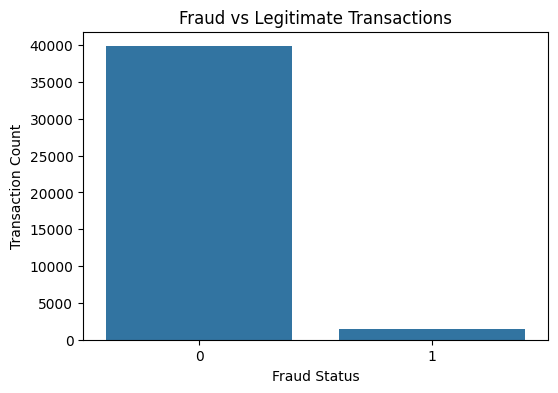

In [ ]:
#Fraud Disturbtion Visualization
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(6,4))

sns.countplot(x = 'is_fraud', data=df)
plt.title('Fraud vs Legitimate Transactions')
plt.xlabel("Fraud Status")
plt.ylabel("Transaction Count")

plt.show()


In [ ]:
This is very important for comparism between Fraud and Legitimate Transactions

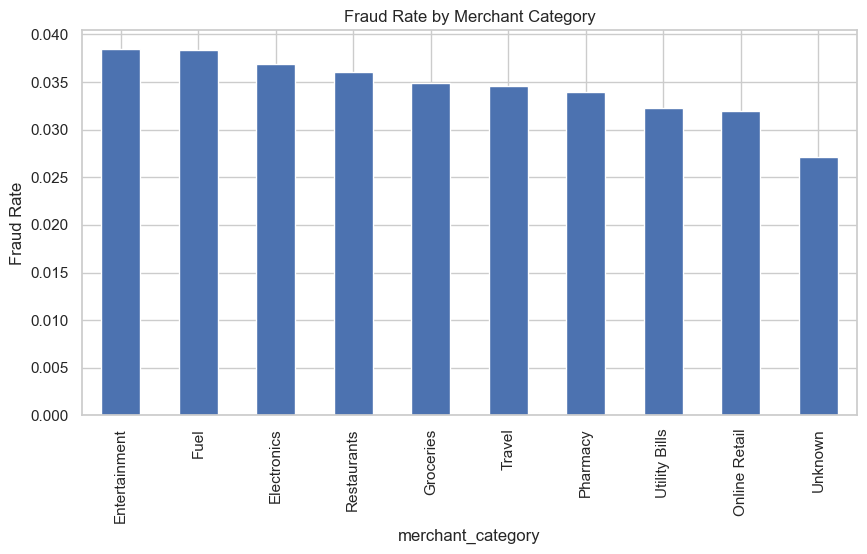

In [ ]:
#Fraud Merchant Category
fraud_category = df.groupby('merchant_category')['is_fraud'].mean().sort_values(ascending=False)

fraud_category.plot(kind='bar', figsize=(10,5))

plt.title("Fraud Rate by Merchant Category")
plt.ylabel("Fraud Rate")
plt.show()


In [ ]:
#High fraud industries often include:

Electronics

Online retail

Travel

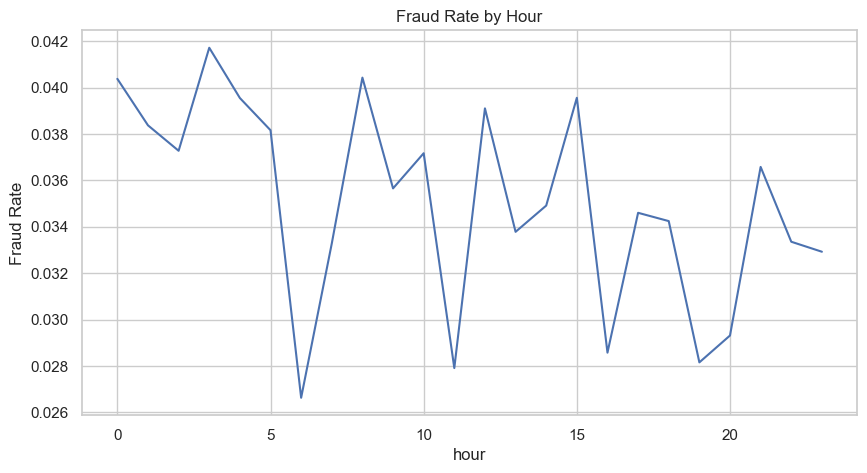

In [ ]:
#Fraud Rate by hour
fraud_hour = df.groupby ("hour")["is_fraud"].mean()
fraud_hour.plot(kind='line',figsize=(10,5))
plt.title("Fraud Rate by Hour")
plt.ylabel("Fraud Rate")

plt.show()


In [ ]:
Fraud spikes late at night (12am-4am)

Text(0.5, 1.0, 'Fraud by Device Type')

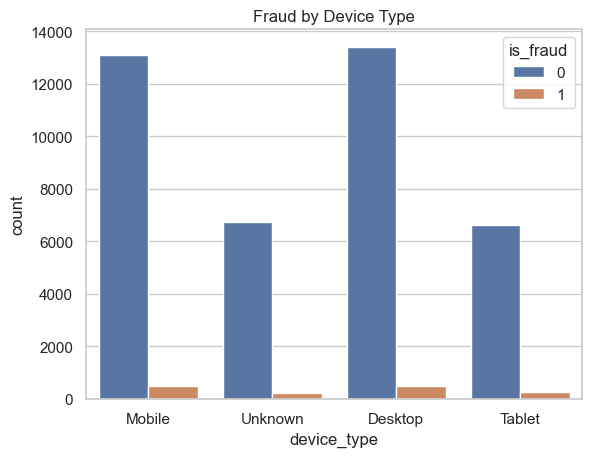

In [ ]:
#Fraud by Device
sns.countplot(x='device_type', hue='is_fraud', data=df)

plt.title("Fraud by Device Type")

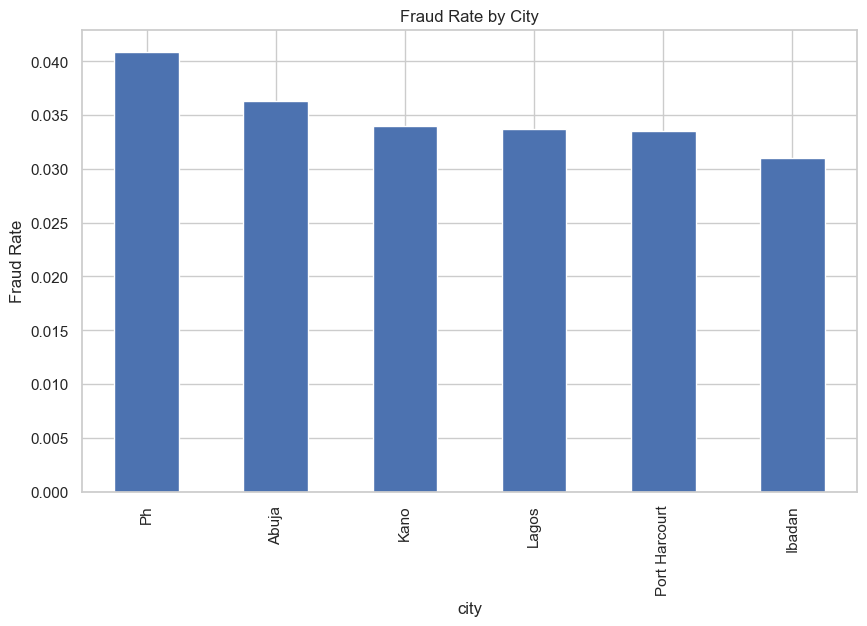

In [ ]:
#Fraud by City
fraud_city = df.groupby('city')['is_fraud'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))

fraud_city.plot(kind='bar')

plt.title("Fraud Rate by City")
plt.ylabel("Fraud Rate")

plt.show()

In [ ]:
Possible insights:

Some cities show higher fraud probability.

Banks use this for risk scoring.

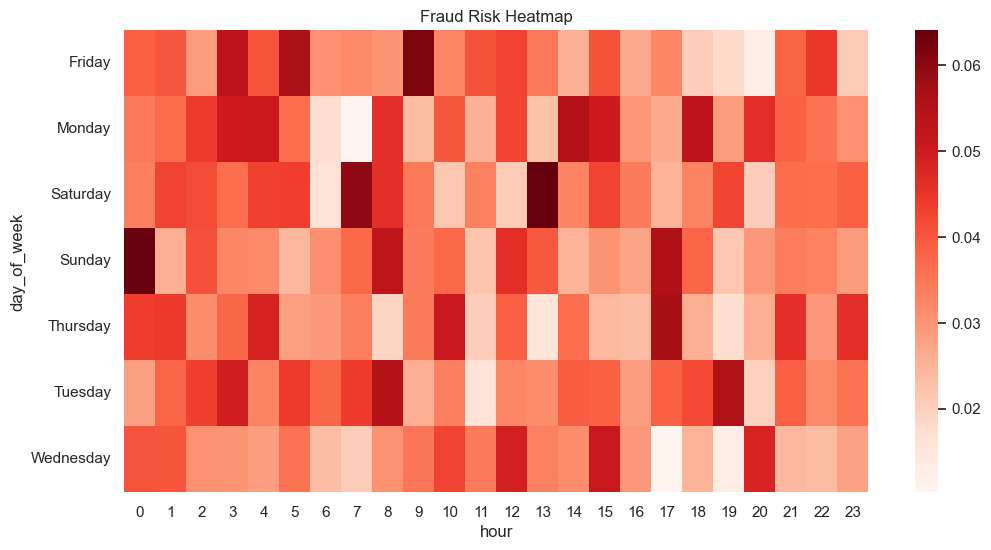

In [ ]:
fraud_matrix = df.pivot_table(
    index='day_of_week',
    columns='hour',
    values='is_fraud',
    aggfunc='mean'
)

plt.figure(figsize=(12,6))

sns.heatmap(fraud_matrix, cmap='Reds')

plt.title("Fraud Risk Heatmap")
plt.show()

In [ ]:
Fraud may spike:

Late night weekends

Early weekday mornings

<p style="font-size:20px;">Strategies to Reduce Credit Card Fraud

Banks use insights like this to design fraud prevention systems.

1️⃣ Transaction Risk Scoring

Flag transactions if:

amount unusually high

new device used

unusual city

late night transactions</p>

2️⃣ <p style="font-size:20px;">Behavioral Monitoring

Compare with customer spending history.

Example:

customer normally spends ₦5,000

suddenly spends ₦250,000

Trigger fraud alert.</p>

3️⃣<p style="font-size:20px;"> Device Fingerprinting

Track:

device ID

browser

IP address

Block unknown devices.</p>

In [ ]:
df.to_excel("cleaned_data_credit_card.xlsx", index= False)

In [ ]:
with pd.ExcelWriter("fraud_analysis.xlsx") as writer:
    df.to_excel(writer, sheet_name="Cleaned Data", index=False)

    # Fraud only
    df[df['is_fraud']==1].to_excel(writer, sheet_name="Fraud Transactions", index=False)

    # Summary KPIs
    summary = pd.DataFrame({
        "Metric": ["Fraud Rate", "Total Fraud Amount"],
        "Value": [
            df['is_fraud'].mean()*100,
            df[df['is_fraud']==1]['transaction_amount'].sum()
        ]
    })

    summary.to_excel(writer, sheet_name="Summary", index=False)